In [1]:
from ultralytics import YOLOE
# Load a segmentation model checkpoint
model = YOLOE("yoloe-11l-seg.pt")


In [19]:
names = ["mini_croissant"]
model.set_classes(names, model.get_text_pe(names))
# Run prediction on the image
image_path = "/home/ubuntu/additional_drive/shwan_data/scripts/all_frames/7_days_mini_croissants__816374020670__5/7_days_mini_croissants__816374020670__5_frame_001.png"

results = model.predict(image_path)
# Extract the segmentation masks (tensor shape [N, H, W])
masks = results[0].masks 


image 1/1 /home/ubuntu/additional_drive/shwan_data/scripts/all_frames/7_days_mini_croissants__816374020670__5/7_days_mini_croissants__816374020670__5_frame_001.png: 640x384 3 mini_croissants, 15.4ms
Speed: 1.3ms preprocess, 15.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)


In [20]:
masks

ultralytics.engine.results.Masks object with attributes:

data: tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]]], device='cuda:0', dtype=torch.uint8)
orig_shape: (1920, 1080)
shape: torch.Size([3, 640, 384])
xy: [array([[ 342.,  990.],
       [ 342., 1002.],
       [ 339., 1005.],
       [ 336., 1005.],
       [ 330., 1011.],
       [ 327., 1011.],
       [ 324., 1014.]

In [ ]:
from ultralytics import YOLOE
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load model
model = YOLOE("yoloe-11l-seg.pt")

# Set your class
names = ["mini_croissant"]
model.set_classes(names, model.get_text_pe(names))

# Predict
image_path = "/home/ubuntu/additional_drive/shwan_data/scripts/all_frames/7_days_mini_croissants__816374020670__5/7_days_mini_croissants__816374020670__5_frame_001.png"
results = model.predict(image_path)

# Load original image in RGB for matplotlib
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
H, W, _ = img.shape

# Extract masks
masks = results[0].masks
if masks is not None:
    mask_data = masks.data.cpu().numpy()  # [N, H_mask, W_mask]
    combined_mask = np.zeros((H, W), dtype=np.uint8)

    for m in mask_data:
        # resize mask
        m_resized = cv2.resize(m, (W, H))
        m_bin = (m_resized > 0.5).astype(np.uint8)
        combined_mask = np.bitwise_or(combined_mask, m_bin)

    # Create coloured overlay (for example green)
    overlay = img.copy()
    overlay[combined_mask > 0] = [0, 255, 0]

    # Blend original + overlay
    blended = (img * 0.7 + overlay * 0.3).astype(np.uint8)

    # Draw class name text on top of image
    text = names[0]  # “mini_croissant”
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1.0
    color = (255, 255, 255)  # white text
    thickness = 2
    # Position text at top-left corner (you can change)
    text_pos = (10, 30)
    # Since img is RGB, cv2.putText expects BGR, so convert temporarily
    blended_bgr = cv2.cvtColor(blended, cv2.COLOR_RGB2BGR)
    cv2.putText(blended_bgr, text, text_pos, font, font_scale, color, thickness, cv2.LINE_AA)
    # Convert back to RGB
    blended = cv2.cvtColor(blended_bgr, cv2.COLOR_BGR2RGB)

else:
    print("⚠️ No masks detected.")
    blended = img

# Show with matplotlib
plt.figure(figsize=(10, 8))
plt.imshow(blended)
plt.axis("off")
plt.title(f"Segmentation Overlay: {names[0]}")
plt.show()



image 1/1 /home/ubuntu/additional_drive/shwan_data/scripts/all_frames/7_days_mini_croissants__816374020670__5/7_days_mini_croissants__816374020670__5_frame_001.png: 640x384 3 mini_croissants, 14.7ms
Speed: 1.2ms preprocess, 14.7ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 384)


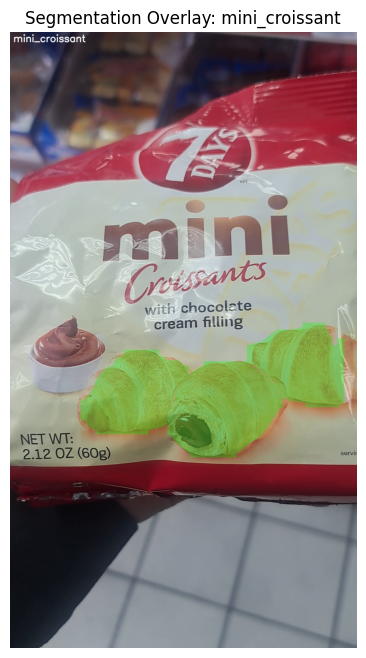